In [ ]:
# train a Random Forest Classifier to engage in thyroid tumor classification
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pathlib import Path

In [ ]:
def load_data(data_dir: Path):
    X_train = pd.read_csv(data_dir / "X_train.csv")
    y_train = pd.read_csv(data_dir / "y_train.csv")
    X_test = pd.read_csv(data_dir / "X_test.csv")
    y_test = pd.read_csv(data_dir / "y_test.csv")

    # Flatten y if it is a column vector
    y_train = y_train.values.ravel()  # pandas DataFrame → 1D array
    y_test = y_test.values.ravel()  # pandas DataFrame → 1D array

    # Encode string labels to integers
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    return X_train, y_train, X_test, y_test

In [23]:
def build_pipeline(X: pd.DataFrame):
    # Determine numeric vs categorical columns
    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    print(f"Numeric cols ({len(numeric_cols)}): {numeric_cols}")
    print(f"Categorical cols ({len(categorical_cols)}): {categorical_cols}")

    numeric_transformer = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop",
    )

    clf = RandomForestClassifier(random_state=42, n_jobs=-1)

    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("clf", clf)])

    return pipe

In [26]:
def main():
    data_dir = Path("data")
    X_train, y_train, X_test, y_test = load_data(data_dir)

    pipe = build_pipeline(X_train)

    # StratifiedKFold for stable splits
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    param_grid = {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4],
    }

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        n_jobs=-1,
        cv=cv,
        verbose=1,
        refit=True,
    )

    grid.fit(X_train, y_train)

    print("\nBest performing Random Forest model:")
    print(grid.best_estimator_)
    print("\nBest hyperparameters:")
    print(grid.best_params_)
    print(f"Best CV AUC: {grid.best_score_:.4f}")

    scoring = {
        "accuracy": make_scorer(accuracy_score),
        "precision": make_scorer(precision_score, pos_label=1),
        "recall": make_scorer(recall_score, pos_label=1),
        "f1": make_scorer(f1_score, pos_label=1),
        "auc": "roc_auc",
    }

    results = []
    
    for params in grid.cv_results_["params"]:
        model = clone(pipe)
        model.set_params(**params)

        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        results.append({
            **params,
            "accuracy": scores["test_accuracy"].mean(),
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
            "f1": scores["test_f1"].mean(),
            "auc": scores["test_auc"].mean()
        })

    metrics_df = pd.DataFrame(results)

    print("\nMetrics for all Random Forest models (averaged across folds):")
    print(metrics_df.sort_values("auc", ascending=False))

    # Save the table
    Path("results").mkdir(exist_ok=True)
    metrics_df.to_csv("results/rf_model_metrics.csv", index=False)

    print("Saved metrics table to results/rf_model_metrics.csv")

    print("\nError metrics for the best performing Random Forest model:")

    best_model = grid.best_estimator_

    scores_best = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    accuracy_best = scores_best["test_accuracy"].mean()
    precision_best = scores_best["test_precision"].mean()
    recall_best = scores_best["test_recall"].mean()
    f1_best = scores_best["test_f1"].mean()
    auc_best = scores_best["test_auc"].mean()

    print(("Error metrics for best model on training data (averaged across folds):"))
    print(f"Accuracy:              {accuracy_best:.4f}")
    print(f"Precision (Malignant): {precision_best:.4f}")
    print(f"Recall (Malignant):    {recall_best:.4f}")
    print(f"F1 (Malignant):        {f1_best:.4f}")
    print(f"AUC:                   {auc_best:.4f}")

    y_prob_best = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
    )[:, 1]  # probabilities for class 1 (Malignant)

    # Create ROC curve
    fpr, tpr, thresholds = roc_curve(y_train, y_prob_best, pos_label=1)
    roc_auc = auc(fpr, tpr)

    # Plot resulting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # random chance line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate', fontweight='bold')
    plt.title('ROC Curve for Best Random Forest Model for Training Data', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha = 0.3)
    plt.savefig("results/best_rf_roc_curve.png", dpi=300)
    plt.show()

    # apply best model to test set
    y_pred_test = best_model.predict(X_test)
    y_prob_test = best_model.predict_proba(X_test)[:, 1]  # probabilities for class 1

    # Compute metrics
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, pos_label=1)
    recall_test = recall_score(y_test, y_pred_test, pos_label=1)
    f1_test = f1_score(y_test, y_pred_test, pos_label=1)
    auc_test = roc_auc_score(y_test, y_prob_test)

    print("Error Metrics for Best Model on Test Set:")
    print(f"Accuracy:  {accuracy_test:.4f}")
    print(f"Precision: {precision_test:.4f}")
    print(f"Recall:    {recall_test:.4f}")
    print(f"F1:        {f1_test:.4f}")
    print(f"AUC:       {auc_test:.4f}")

    # --- Plot ROC curve for test set ---
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_test, pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Test ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate', fontweight='bold')
    plt.title('ROC Curve for Best Random Forest Model on Test Set', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha = 0.3)
    Path("results").mkdir(exist_ok=True)
    plt.savefig("results/best_rf_test_roc_curve.png", dpi=300)
    plt.show()
    

Numeric cols (8): ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Risk_Factor_Score', 'TSH_Nodule_Interact', 'T3_TSH_Ratio']
Categorical cols (9): ['Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes']
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best performing Random Forest model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'TSH_Level',
                                                   'T3_Level', 'T4_Level',
                                                   'Nodule_Size',
                                                   'Risk_Factor_Score',
                                                   'TSH_Nodule_Interact'

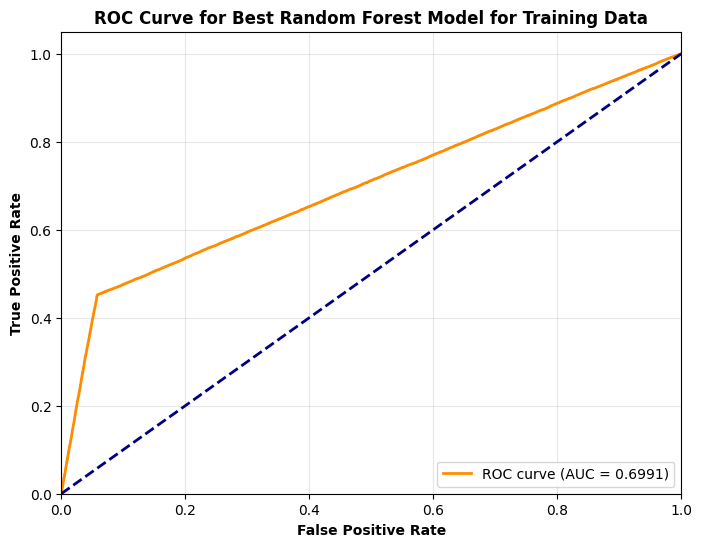

Error Metrics for Best Model on Test Set:
Accuracy:  0.8256
Precision: 0.6945
Recall:    0.4469
F1:        0.5439
AUC:       0.6936


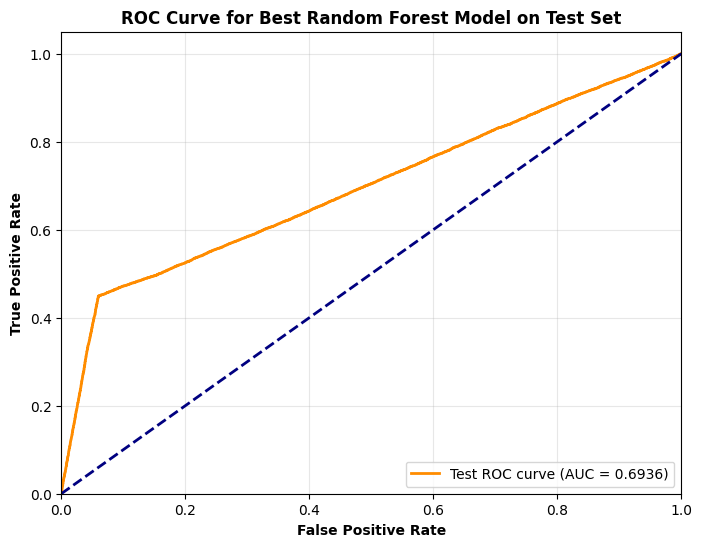

In [27]:
if __name__ == "__main__":
    main()